In [1]:
import json
import sys
sys.path.append("../")

from src.classification.paragraph_classifier import (
    ClassificationConfig,
    run_classification_pipeline,
    save_results,
)

import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings('ignore')

In [2]:
clusters = {"Cluster 0":
  {"Ministry_of_Power_MoP_",
  "Ministry_of_New_and_Renewable_Energy_MNRE_",
  "Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_",
  "Ministry_of_Earth_Sciences_MoES_"},

"Cluster 1":
  {"Ministry_of_Science_and_Technology_MST_",
  "Ministry_of_Textiles_MoT_",
  "Ministry_of_Micro_Small_Medium_Enterprises_MoME_"},

"Cluster 2":
  {"Ministry_of_Health_and_Family_Welfare_MoHFW_",
  "Ministry_of_AYUSH_MoA_"},

"Cluster 3":
  {"Ministry_of_Commerce_and_Industry_MoCI_",
  "Ministry_of_Corporate_Affairs_MCA_",
  "Ministry_of_Law_and_Justice_MoLJ_",
  "Ministry_of_External_Affairs_MEA_",
  "Ministry_of_Planning_MoP_",
  "Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_",
  "Ministry_of_Finance_MoF_",
  "Ministry_of_Defence_MoD_",
  "Ministry_of_Development_of_North_Eastern_Region_MDoNER_"},

"Cluster 4":
  {"Ministry_of_Women_and_Child_Development_MoWCD_",
  "Ministry_of_Housing_and_Urban_Affairs_MoHUA_",
  "Ministry_of_Home_Affairs_MHA_",
  "Ministry_of_Minority_Affairs_MoMA_",
  "Ministry_of_Social_Justice_and_Empowerment_MoSJE_",
  "Ministry_of_Culture",
  "Ministry_of_Tribal_Affairs_MoTA_",
  "Ministry_of_Rural_Development_MoRD_",
  "Ministry_of_Panchayati_Raj_MoPR_"},

"Cluster 5":
  {"Ministry_of_Heavy_Industries_MoHI_"},

"Cluster 6":
  {"Ministry_of_Statistics_and_Programme_Implementation_MoSPI_"},

"Cluster 7":
  {"Ministry_of_Tourism_MoT_"},

"Cluster 8":
  {"Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_",
  "Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_",
  "Ministry_of_Food_Processing_Industries_MoFPI_",
  "Ministry_of_Cooperation_MoC_",
  "Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_",
  "Ministry_of_Chemicals_and_Fertilizers_MoCF_"},

"Cluster 9":
  {"Ministry_of_Education_MoE_",
  "Ministry_of_Labour_and_Employment_MoLE_",
  "Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_"},

"Cluster 10":
  {"Ministry_of_Mines_MoM_",
  "Ministry_of_Petroleum_and_Natural_Gas_MoPNG_",
  "Ministry_of_Steel_MoS_",
  "Ministry_of_Coal_MoC_"},

"Cluster 11":
  {"Ministry_of_Electronics_and_Information_Technology_MeitY_",
  "Ministry_of_Information_and_Broadcasting_MIB_",
  "Ministry_of_Communications_MoC_"},

"Cluster 12":
  {"Ministry_of_Parliamentary_Affairs_MPA_",
  "Ministry_of_Youth_Affairs_and_Sports_MoYAS_"},

"Cluster 13":
  {"Ministry_of_Road_Transport_and_Highways_MoRTH_",
  "Ministry_of_Railways_MoR_",
  "Ministry_of_Ports_Shipping_and_Waterways_MoPSW_"},

"Cluster 14":
  {"Ministry_of_Civil_Aviation_MoCA_"},

"Cluster 15":
  {"Ministry_of_Jal_Shakti_MoJS_"}
}

In [3]:
# Define all method configurations
methods_config = {
    "vocab": {
        "method": "vocab",
        "params": {}
    },
    "doc_word_topic": {
        "method": "doc_word_topic",
        "params": {}
    },
    "ministry_embedding": {
        "method": "ministry_embedding",
        "params": {"embedding_file": "data/embeddings/ministry_embeddings.json"}
    },
    "ministry_embedding_v1": {
        "method": "ministry_embedding",
        "params": {"embedding_file": "data/embeddings/ministry_embeddings1.json"}
    },
    "ministry_embedding_v2": {
        "method": "ministry_embedding",
        "params": {"embedding_file": "data/embeddings/ministry_embeddings2.json"}
    },
    "ministry_embedding_multi": {
        "method": "ministry_embedding_multi",
        "params": {"aggregation": "topk", "top_k": 3, "embedding_file": "data/embeddings/ministry_embeddings3.json"}
    },
    "topic_embedding": {
        "method": "topic_embedding",
        "params": {}
    }
}

In [4]:
# Store all results
all_results = []

# Run all combinations (method vs baseline_method)
for method_name, baseline_name in product(methods_config.keys(), repeat=2):
    if method_name == baseline_name:
        continue  # Skip self-comparison
    
    method_config = methods_config[method_name]
    baseline_config = methods_config[baseline_name]
    
    print(f"\n{'='*60}")
    print(f"Testing: {method_name} vs baseline: {baseline_name}")
    print(f"{'='*60}")
    
    try:
        # Build configuration
        cfg = ClassificationConfig(
            pdf_path="data/uploads/test.pdf",
            method=method_config["method"],
            baseline_method=baseline_config["method"],
            topic_state_file="data/topic_modeling/state.csv",
            ministry_profiles_dir="data/ministry_profiles",
            stopword_files=("data/stopwords/GBparl_stopwords-empirical.txt", "data/stopwords/stopwords.txt"),
            validator_vocab_path="data/vocabulary/parliament_vocab.txt",
            vocab_file="data/vocabulary/ministry_tfidf_vocab.json",
            ministry_embedding_file=method_config["params"].get("embedding_file", "data/embeddings/ministry_embeddings.json"),
            topic_embedding_file="data/embeddings/topic_embeddings.json",
            topic_mapping_file="data/topic_modeling/top_ministry_per_topic.csv",
            model_name="all-MiniLM-L6-v2",
            model_cache_folder="models",
            ministry_clusters=clusters,
        )
        
        # Add extra params if needed
        if "aggregation" in method_config["params"]:
            cfg.primary_params = {"aggregation": method_config["params"]["aggregation"], "top_k": method_config["params"]["top_k"]}
        if "aggregation" in baseline_config["params"]:
            cfg.baseline_params = {"aggregation": baseline_config["params"]["aggregation"], "top_k": baseline_config["params"]["top_k"]}
        
        # Run pipeline
        output = run_classification_pipeline(cfg)
        
        # Extract metrics and store
        metrics = output.get("metrics", {})
        result_row = {
            "method": method_name,
            "baseline_method": baseline_name,
            **metrics
        }
        all_results.append(result_row)
        
        print(f"✓ Success - Metrics: {metrics}")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        result_row = {
            "method": method_name,
            "baseline_method": baseline_name,
            "error": str(e)
        }
        all_results.append(result_row)



Testing: vocab vs baseline: doc_word_topic
✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 26, 'exact_match_rate': 0.143646408839779, 'top2_error_count': 10, 'top3_error_count': 17, 'top4_error_count': 26, 'top5_error_count': 34, 'top2_error_rate': 0.055248618784530384, 'top3_error_rate': 0.09392265193370165, 'top4_error_rate': 0.143646408839779, 'top5_error_rate': 0.1878453038674033, 'same_cluster_match_count': 45, 'same_cluster_match_rate': 0.24861878453038674, 'same_topic_family_match_count': 16, 'same_topic_family_match_rate': 0.08839779005524862}

Testing: vocab vs baseline: ministry_embedding


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 28, 'exact_match_rate': 0.15469613259668508, 'top2_error_count': 18, 'top3_error_count': 30, 'top4_error_count': 39, 'top5_error_count': 51, 'top2_error_rate': 0.09944751381215469, 'top3_error_rate': 0.16574585635359115, 'top4_error_rate': 0.2154696132596685, 'top5_error_rate': 0.281767955801105, 'same_cluster_match_count': 52, 'same_cluster_match_rate': 0.287292817679558, 'same_topic_family_match_count': 0, 'same_topic_family_match_rate': 0.0}

Testing: vocab vs baseline: ministry_embedding_v1


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 5, 'exact_match_rate': 0.027624309392265192, 'top2_error_count': 24, 'top3_error_count': 40, 'top4_error_count': 47, 'top5_error_count': 54, 'top2_error_rate': 0.13259668508287292, 'top3_error_rate': 0.22099447513812154, 'top4_error_rate': 0.2596685082872928, 'top5_error_rate': 0.2983425414364641, 'same_cluster_match_count': 20, 'same_cluster_match_rate': 0.11049723756906077, 'same_topic_family_match_count': 5, 'same_topic_family_match_rate': 0.027624309392265192}

Testing: topic_embedding vs baseline: ministry_embedding_multi


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 5, 'exact_match_rate': 0.027624309392265192, 'top2_error_count': 24, 'top3_error_count': 40, 'top4_error_count': 47, 'top5_error_count': 54, 'top2_error_rate': 0.13259668508287292, 'top3_error_rate': 0.22099447513812154, 'top4_error_rate': 0.2596685082872928, 'top5_error_rate': 0.2983425414364641, 'same_cluster_match_count': 20, 'same_cluster_match_rate': 0.11049723756906077, 'same_topic_family_match_count': 5, 'same_topic_family_match_rate': 0.027624309392265192}


In [5]:
# Create comprehensive results DataFrame
results_df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print(f"COMPLETE RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Total comparisons: {len(results_df)}")
print(f"\nResults DataFrame Shape: {results_df.shape}")
print(f"\nColumns: {list(results_df.columns)}")


COMPLETE RESULTS SUMMARY
Total comparisons: 42

Results DataFrame Shape: (42, 18)

Columns: ['method', 'baseline_method', 'num_paragraphs', 'exact_match_count', 'exact_match_rate', 'top2_error_count', 'top3_error_count', 'top4_error_count', 'top5_error_count', 'top2_error_rate', 'top3_error_rate', 'top4_error_rate', 'top5_error_rate', 'same_cluster_match_count', 'same_cluster_match_rate', 'same_topic_family_match_count', 'same_topic_family_match_rate', 'error']


In [6]:
# Display full results DataFrame
print("DETAILED RESULTS TABLE")
print("="*100)
print(results_df.to_string())
print("\n")

DETAILED RESULTS TABLE
                      method           baseline_method  num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate                                                                                     error
0                      vocab            doc_word_topic           181.0               26.0          0.143646              10.0              17.0              26.0              34.0         0.055249         0.093923         0.143646         0.187845                      45.0                 0.248619                           16.0                      0.088398                                                                                       NaN
1                      vocab        ministry_embedding           181.0       

In [13]:
# Summary statistics by method (as primary method)
print("AVERAGE PERFORMANCE BY METHOD (Primary Method)")
print("="*100)
method_summary = results_df.groupby("method").agg({
    col: "mean" for col in results_df.columns if col not in ["method", "baseline_method", "error"]
}).round(4)
print(method_summary.to_string())
print("\n")

AVERAGE PERFORMANCE BY METHOD (Primary Method)
                          num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate
method                                                                                                                                                                                                                                                                                                                                   
doc_word_topic                     181.0            26.0000            0.1436           18.8333           32.0000           40.0000           48.3333           0.1041           0.1768           0.2210           0.2670                   48.1667                   0.2661                        1

In [14]:
# Summary statistics by baseline method
print("AVERAGE PERFORMANCE BY BASELINE METHOD")
print("="*100)
baseline_summary = results_df.groupby("baseline_method").agg({
    col: "mean" for col in results_df.columns if col not in ["method", "baseline_method", "error"]
}).round(4)
print(baseline_summary.to_string())
print("\n")

AVERAGE PERFORMANCE BY BASELINE METHOD
                          num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate
baseline_method                                                                                                                                                                                                                                                                                                                          
doc_word_topic                     181.0            35.5000            0.1961           15.6667           24.3333           31.8333           37.5000           0.0866           0.1344           0.1759           0.2072                   54.5000                   0.3011                        24.6667  

In [9]:
# Create a heatmap matrix: method vs baseline_method
print("METRICS COMPARISON MATRIX (Method vs Baseline)")
print("="*100)

# Get numeric columns (metric columns)
metric_cols = [col for col in results_df.columns if col not in ["method", "baseline_method", "error"]]

if metric_cols:
    for metric in metric_cols[:1]:  # Show first metric as example
        try:
            pivot_table = results_df.pivot_table(
                index="method",
                columns="baseline_method",
                values=metric,
                aggfunc="first"
            )
            print(f"\nMetric: {metric}")
            print(pivot_table.round(4).to_string())
        except Exception as e:
            print(f"Could not create pivot table for {metric}: {e}")


METRICS COMPARISON MATRIX (Method vs Baseline)

Metric: num_paragraphs
baseline_method           doc_word_topic  ministry_embedding  ministry_embedding_multi  ministry_embedding_v1  ministry_embedding_v2  topic_embedding  vocab
method                                                                                                                                                      
doc_word_topic                       NaN               181.0                     181.0                  181.0                  181.0            181.0  181.0
ministry_embedding                 181.0                 NaN                     181.0                  181.0                  181.0            181.0  181.0
ministry_embedding_multi           181.0                 NaN                       NaN                    NaN                    NaN            181.0  181.0
ministry_embedding_v1              181.0               181.0                     181.0                    NaN                  181.0            

In [10]:

# Show errors if any
errors = results_df[results_df["error"].notna()] if 'error' in results_df.columns else pd.DataFrame()
if len(errors) > 0:
    print("ERRORS ENCOUNTERED:")
    print("="*100)
    for idx, row in errors.iterrows():
        print(f"{row['method']} vs {row['baseline_method']}: {row['error']}")
else:
    print("No errors - all comparisons completed successfully!")
    
# Show comparison count
print(f"\nTotal unique methods: {results_df['method'].nunique()}")
print(f"Methods: {sorted(results_df['method'].unique())}")


ERRORS ENCOUNTERED:
ministry_embedding_multi vs ministry_embedding: Incompatible dimension for X and Y matrices: X.shape[1] == 384 while Y.shape[1] == 19968
ministry_embedding_multi vs ministry_embedding_v1: Incompatible dimension for X and Y matrices: X.shape[1] == 384 while Y.shape[1] == 19968
ministry_embedding_multi vs ministry_embedding_v2: Incompatible dimension for X and Y matrices: X.shape[1] == 384 while Y.shape[1] == 19968

Total unique methods: 7
Methods: ['doc_word_topic', 'ministry_embedding', 'ministry_embedding_multi', 'ministry_embedding_v1', 'ministry_embedding_v2', 'topic_embedding', 'vocab']


In [16]:
# Find best performing combinations for each metric
metric_cols = [col for col in results_df.columns if col not in ["method", "baseline_method", "error"]]

print("BEST PERFORMING COMBINATIONS BY METRIC")
print("="*100)

for metric in metric_cols:
    try:
        valid_results = results_df[results_df[metric].notna()].sort_values(metric, ascending=False)
        if len(valid_results) > 0:
            print(f"\n{metric}:")
            # remove rows where both method and baseline_method comtain ministry_embedding
            valid_results = valid_results[~(valid_results["method"].str.contains("ministry_embedding") & valid_results["baseline_method"].str.contains("ministry_embedding"))]
            top_10 = valid_results.head(10)[["method", "baseline_method", metric]]
            print(top_10.to_string(index=False))
    except Exception as e:
        print(f"Could not analyze {metric}: {e}")


BEST PERFORMING COMBINATIONS BY METRIC

num_paragraphs:
        method          baseline_method  num_paragraphs
         vocab           doc_word_topic           181.0
         vocab       ministry_embedding           181.0
         vocab    ministry_embedding_v1           181.0
         vocab    ministry_embedding_v2           181.0
         vocab ministry_embedding_multi           181.0
         vocab          topic_embedding           181.0
doc_word_topic                    vocab           181.0
doc_word_topic       ministry_embedding           181.0
doc_word_topic    ministry_embedding_v1           181.0
doc_word_topic    ministry_embedding_v2           181.0

exact_match_count:
                  method          baseline_method  exact_match_count
ministry_embedding_multi           doc_word_topic               58.0
   ministry_embedding_v2           doc_word_topic               52.0
ministry_embedding_multi                    vocab               44.0
   ministry_embedding_v1        

In [12]:
# # Save results to CSV and display summary
# output_path = "data/outputs/comprehensive_comparison_results.csv"
# results_df.to_csv(output_path, index=False)
# print(f"Results saved to: {output_path}\n")

In [6]:
# reference labels from chatgpt
chatgpt_labels = {
0:'Ministry_of_Parliamentary_Affairs_MPA_',
1:'Ministry_of_Parliamentary_Affairs_MPA_',
2:'Ministry_of_Parliamentary_Affairs_MPA_',
3:'Ministry_of_Finance_MoF_',
4:'Ministry_of_Finance_MoF_',
5:'Ministry_of_Finance_MoF_',
6:'Ministry_of_Culture',
7:'Ministry_of_Finance_MoF_',
8:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
9:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
10:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
11:'Ministry_of_Rural_Development_MoRD_',
12:'Ministry_of_Rural_Development_MoRD_',
13:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
14:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
15:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
16:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
17:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
18:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
19:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
20:'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_',
21:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
22:'Ministry_of_Chemicals_and_Fertilizers_MoCF_',
23:'Ministry_of_Communications_MoC_',
24:'Ministry_of_Communications_MoC_',
25:'Ministry_of_Commerce_and_Industry_MoCI_',
26:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
27:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
28:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
29:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
30:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
31:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
32:'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',
33:'Ministry_of_Commerce_and_Industry_MoCI_',
34:'Ministry_of_Commerce_and_Industry_MoCI_',
35:'Ministry_of_Food_Processing_Industries_MoFPI_',
36:'Ministry_of_Heavy_Industries_MoHI_',
37:'Ministry_of_New_and_Renewable_Energy_MNRE_',
38:'Ministry_of_Women_and_Child_Development_MoWCD_',
39:'Ministry_of_Education_MoE_',
40:'Ministry_of_Communications_MoC_',
41:'Ministry_of_Education_MoE_',
42:'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',
43:'Ministry_of_Education_MoE_',
44:'Ministry_of_Education_MoE_',
45:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
46:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
47:'Ministry_of_Labour_and_Employment_MoLE_',
48:'Ministry_of_Finance_MoF_',
49:'Ministry_of_Labour_and_Employment_MoLE_',
50:'Ministry_of_Finance_MoF_',
51:'Ministry_of_Finance_MoF_',
52:'Ministry_of_Jal_Shakti_MoJS_',
53:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
54:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
55:'Ministry_of_Power_MoP_',
56:'Ministry_of_Atomic_Energy',
57:'Ministry_of_Heavy_Industries_MoHI_',
58:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',
59:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',
60:'Ministry_of_Civil_Aviation_MoCA_',
61:'Ministry_of_Civil_Aviation_MoCA_',
62:'Ministry_of_Mines_MoM_',
63:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
64:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
65:'Ministry_of_Tourism_MoT_',
66:'Ministry_of_Tourism_MoT_',
67:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
68:'Ministry_of_Science_and_Technology_MST_',
69:'Ministry_of_Science_and_Technology_MST_',
70:'Ministry_of_Science_and_Technology_MST_',
71:'Ministry_of_Commerce_and_Industry_MoCI_',
72:'Ministry_of_Commerce_and_Industry_MoCI_',
73:'Ministry_of_Commerce_and_Industry_MoCI_',
74:'Ministry_of_Commerce_and_Industry_MoCI_',
75:'Ministry_of_Commerce_and_Industry_MoCI_',
76:'Ministry_of_Communications_MoC_',
77:'Ministry_of_Finance_MoF_',
78:'Ministry_of_Finance_MoF_',
79:'Ministry_of_Finance_MoF_',
80:'Ministry_of_Finance_MoF_',
81:'Ministry_of_Finance_MoF_',
82:'Ministry_of_Corporate_Affairs_MCA_',
83:'Ministry_of_Finance_MoF_',
84:'Ministry_of_Finance_MoF_',
85:'Ministry_of_Finance_MoF_',
86:'Ministry_of_Law_and_Justice_MoLJ_',
87:'Ministry_of_Finance_MoF_',
88:'Ministry_of_Finance_MoF_',
89:'Ministry_of_Finance_MoF_',
90:'Ministry_of_Finance_MoF_',
91:'Ministry_of_Finance_MoF_',
92:'Ministry_of_Finance_MoF_',
93:'Ministry_of_Finance_MoF_',
94:'Ministry_of_Finance_MoF_',
95:'Ministry_of_Finance_MoF_',
96:'Ministry_of_Finance_MoF_',
97:'Ministry_of_Finance_MoF_',
98:'Ministry_of_Finance_MoF_',
99:'Ministry_of_Finance_MoF_',
100:'Ministry_of_Finance_MoF_',
101:'Ministry_of_Finance_MoF_',
102:'Ministry_of_Finance_MoF_',
103:'Ministry_of_Finance_MoF_',
104:'Ministry_of_Finance_MoF_',
105:'Ministry_of_Finance_MoF_',
106:'Ministry_of_Finance_MoF_',
107:'Ministry_of_Finance_MoF_',
108:'Ministry_of_Finance_MoF_',
109:'Ministry_of_Finance_MoF_',
110:'Ministry_of_Finance_MoF_',
111:'Ministry_of_Finance_MoF_',
112:'Ministry_of_Finance_MoF_',
113:'Ministry_of_Finance_MoF_',
114:'Ministry_of_Finance_MoF_',
115:'Ministry_of_Finance_MoF_',
116:'Ministry_of_Finance_MoF_',
117:'Ministry_of_Finance_MoF_',
118:'Ministry_of_Finance_MoF_',
119:'Ministry_of_Finance_MoF_',
120:'Ministry_of_Finance_MoF_',
121:'Ministry_of_Finance_MoF_',
122:'Ministry_of_Finance_MoF_',
123:'Ministry_of_Finance_MoF_',
124:'Ministry_of_Finance_MoF_',
125:'Ministry_of_Finance_MoF_',
126:'Ministry_of_Finance_MoF_',
127:'Ministry_of_Finance_MoF_',
128:'Ministry_of_Finance_MoF_',
129:'Ministry_of_Finance_MoF_',
130:'Ministry_of_Finance_MoF_',
131:'Ministry_of_Finance_MoF_',
132:'Ministry_of_Finance_MoF_',
133:'Ministry_of_Finance_MoF_',
134:'Ministry_of_Finance_MoF_',
135:'Ministry_of_Finance_MoF_',
136:'Ministry_of_Finance_MoF_',
137:'Ministry_of_Finance_MoF_',
138:'Ministry_of_Finance_MoF_',
139:'Ministry_of_Finance_MoF_',
140:'Ministry_of_Finance_MoF_',
141:'Ministry_of_Finance_MoF_',
142:'Ministry_of_Finance_MoF_',
143:'Ministry_of_Finance_MoF_',
144:'Ministry_of_Finance_MoF_',
145:'Ministry_of_Finance_MoF_',
146:'Ministry_of_Finance_MoF_',
147:'Ministry_of_Finance_MoF_',
148:'Ministry_of_Finance_MoF_',
149:'Ministry_of_Finance_MoF_',
150:'Ministry_of_Finance_MoF_',
151:'Ministry_of_Finance_MoF_',
152:'Ministry_of_Finance_MoF_',
153:'Ministry_of_Finance_MoF_',
154:'Ministry_of_Finance_MoF_',
155:'Ministry_of_Finance_MoF_',
156:'Ministry_of_Finance_MoF_',
157:'Ministry_of_Finance_MoF_',
158:'Ministry_of_Finance_MoF_',
159:'Ministry_of_Finance_MoF_',
160:'Ministry_of_Finance_MoF_',
161:'Ministry_of_Finance_MoF_',
162:'Ministry_of_Finance_MoF_',
163:'Ministry_of_Finance_MoF_',
164:'Ministry_of_Finance_MoF_',
165:'Ministry_of_Finance_MoF_',
166:'Ministry_of_Finance_MoF_',
167:'Ministry_of_Finance_MoF_',
168:'Ministry_of_Finance_MoF_',
169:'Ministry_of_Finance_MoF_',
170:'Ministry_of_Finance_MoF_',
171:'Ministry_of_Finance_MoF_',
172:'Ministry_of_Finance_MoF_',
173:'Ministry_of_Finance_MoF_',
174:'Ministry_of_Finance_MoF_',
175:'Ministry_of_Parliamentary_Affairs_MPA_',
176:'Ministry_of_Parliamentary_Affairs_MPA_',
177:'Ministry_of_Parliamentary_Affairs_MPA_',
178:'Ministry_of_Parliamentary_Affairs_MPA_',
179:'Ministry_of_Parliamentary_Affairs_MPA_',
180:'Ministry_of_Parliamentary_Affairs_MPA_'
}

In [7]:
print(f"Loaded {len(chatgpt_labels)} reference labels")

Loaded 181 reference labels


In [12]:
# Store all results
new_all_results = []

for method_name in methods_config.keys():
    method_config = methods_config[method_name]
    
    print(f"\n{'='*60}")
    print(f"Testing: {method_name} vs baseline: chatgpt_labels")
    print(f"{'='*60}")
    
    try:
        # Build configuration
        cfg = ClassificationConfig(
            pdf_path="data/uploads/test.pdf",
            method=method_config["method"],
            reference_labels=chatgpt_labels,
            topic_state_file="data/topic_modeling/state.csv",
            ministry_profiles_dir="data/ministry_profiles",
            stopword_files=("data/stopwords/GBparl_stopwords-empirical.txt", "data/stopwords/stopwords.txt"),
            validator_vocab_path="data/vocabulary/parliament_vocab.txt",
            vocab_file="data/vocabulary/ministry_tfidf_vocab.json",
            ministry_embedding_file=method_config["params"].get("embedding_file", "data/embeddings/ministry_embeddings.json"),
            topic_embedding_file="data/embeddings/topic_embeddings.json",
            topic_mapping_file="data/topic_modeling/top_ministry_per_topic.csv",
            model_name="all-MiniLM-L6-v2",
            model_cache_folder="models",
            ministry_clusters=clusters,
        )
        
        # Add extra params if needed
        if "aggregation" in method_config["params"]:
            cfg.primary_params = {"aggregation": method_config["params"]["aggregation"], "top_k": method_config["params"]["top_k"]}
        
        # Run pipeline
        output = run_classification_pipeline(cfg)
        
        # Extract metrics and store
        metrics = output.get("metrics", {})
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            **metrics
        }
        new_all_results.append(result_row)
        
        print(f"✓ Success - Metrics: {metrics}")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            "error": str(e)
        }
        new_all_results.append(result_row)



Testing: vocab vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 22, 'exact_match_rate': 0.12154696132596685, 'top2_error_count': 11, 'top3_error_count': 13, 'top4_error_count': 15, 'top5_error_count': 21, 'top2_error_rate': 0.06077348066298342, 'top3_error_rate': 0.0718232044198895, 'top4_error_rate': 0.08287292817679558, 'top5_error_rate': 0.11602209944751381, 'same_cluster_match_count': 46, 'same_cluster_match_rate': 0.2541436464088398, 'same_topic_family_match_count': 16, 'same_topic_family_match_rate': 0.08839779005524862}

Testing: doc_word_topic vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 21, 'exact_match_rate': 0.11602209944751381, 'top2_error_count': 16, 'top3_error_count': 27, 'top4_error_count': 38, 'top5_error_count': 50, 'top2_error_rate': 0.08839779005524862, 'top3_error_rate': 0.14917127071823205, 'top4_error_rate': 0.20994475138121546, 'top5_error_rate': 0.27624309392265195, '

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 15, 'exact_match_rate': 0.08287292817679558, 'top2_error_count': 12, 'top3_error_count': 25, 'top4_error_count': 32, 'top5_error_count': 38, 'top2_error_rate': 0.06629834254143646, 'top3_error_rate': 0.13812154696132597, 'top4_error_rate': 0.17679558011049723, 'top5_error_rate': 0.20994475138121546, 'same_cluster_match_count': 43, 'same_cluster_match_rate': 0.23756906077348067, 'same_topic_family_match_count': 12, 'same_topic_family_match_rate': 0.06629834254143646}

Testing: ministry_embedding_v1 vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 47, 'exact_match_rate': 0.2596685082872928, 'top2_error_count': 11, 'top3_error_count': 21, 'top4_error_count': 26, 'top5_error_count': 36, 'top2_error_rate': 0.06077348066298342, 'top3_error_rate': 0.11602209944751381, 'top4_error_rate': 0.143646408839779, 'top5_error_rate': 0.19889502762430938, 'same_cluster_match_count': 80, 'same_cluster_match_rate': 0.4419889502762431, 'same_topic_family_match_count': 41, 'same_topic_family_match_rate': 0.2265193370165746}

Testing: topic_embedding vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 181, 'exact_match_count': 0, 'exact_match_rate': 0.0, 'top2_error_count': 23, 'top3_error_count': 40, 'top4_error_count': 58, 'top5_error_count': 69, 'top2_error_rate': 0.1270718232044199, 'top3_error_rate': 0.22099447513812154, 'top4_error_rate': 0.32044198895027626, 'top5_error_rate': 0.3812154696132597, 'same_cluster_match_count': 14, 'same_cluster_match_rate': 0.07734806629834254, 'same_topic_family_match_count': 0, 'same_topic_family_match_rate': 0.0}


In [13]:
results_df = pd.DataFrame(new_all_results)
print(results_df.to_string())

                     method baseline_method  num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate
0                     vocab  chatgpt_labels             181                 22          0.121547                11                13                15                21         0.060773         0.071823         0.082873         0.116022                        46                 0.254144                             16                      0.088398
1            doc_word_topic  chatgpt_labels             181                 21          0.116022                16                27                38                50         0.088398         0.149171         0.209945         0.276243                        47                 0.259669               

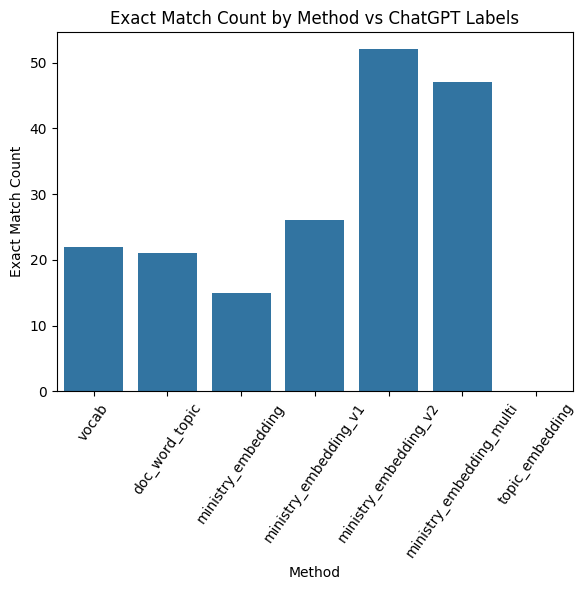

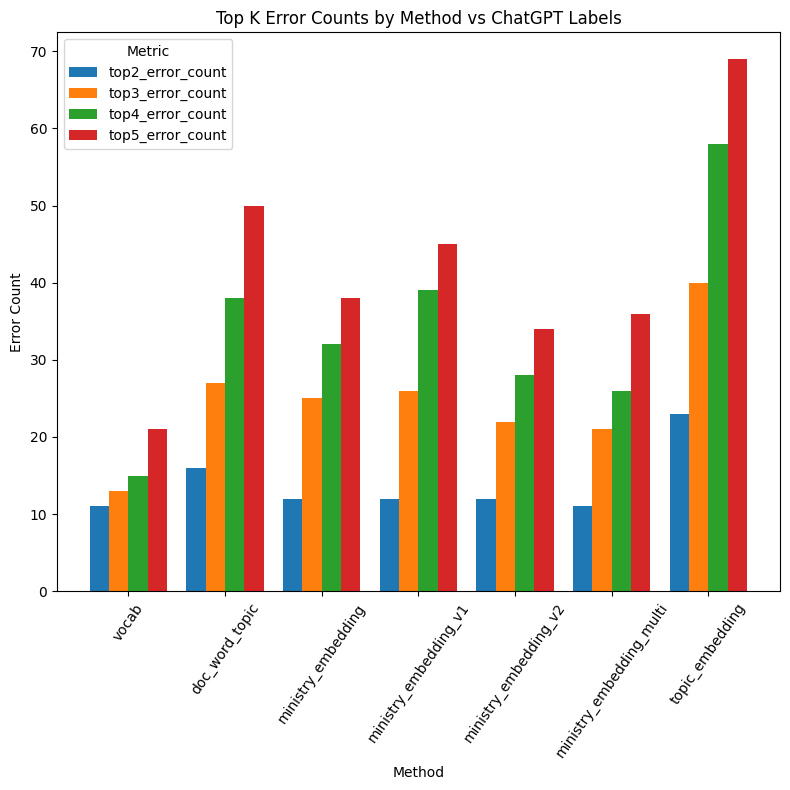

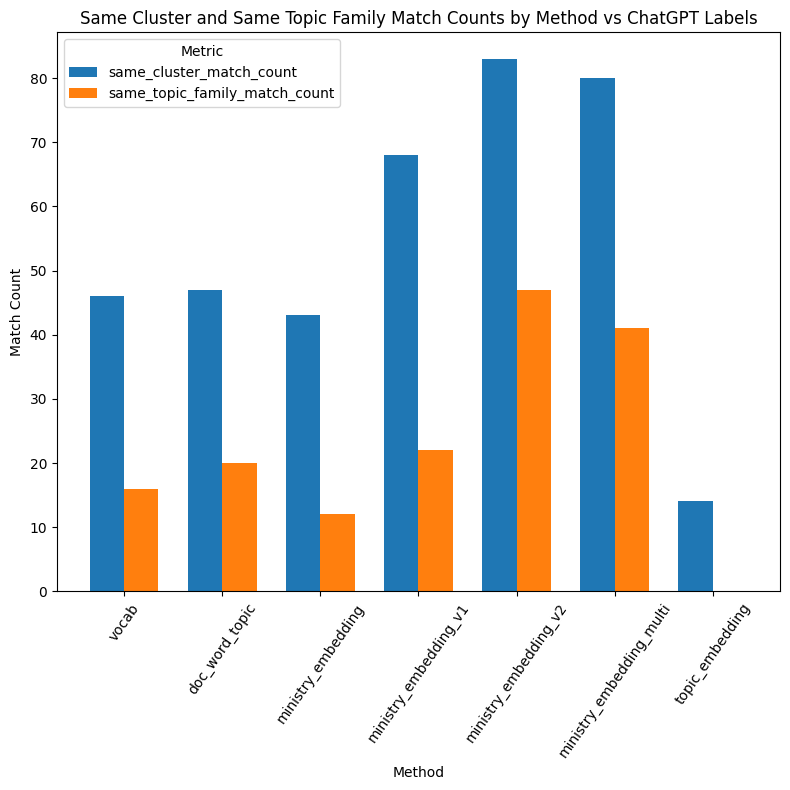

In [22]:
# i want to plot following subgraphs-
# 1. Bar chart comparing exact_match_count for each method against chatgpt_labels
# 2. Bar chart comparing top_2_error_count, top_3_error_count, top_4_error_count, top_5_error_count for each method against chatgpt_labels
# 3. Bar chart comparing same_cluster_match_count, same_topic_family_match_count for each method against chatgpt_labels

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar chart for exact_match_count
plt.figure(figsize=(6, 6))
sns.barplot(x="method", y="exact_match_count", data=results_df)
plt.title("Exact Match Count by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Exact Match Count")
plt.xticks(rotation=55)
plt.tight_layout()
plt.show()

# 2. Bar chart for top_k_error_counts (joint barr  plot, side by side bars for each error)
top_k_metrics = ["top2_error_count", "top3_error_count", "top4_error_count", "top5_error_count"]
plt.figure(figsize=(8,8))
bar_width = 0.2
index = range(len(results_df))
for i, metric in enumerate(top_k_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Top K Error Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Error Count")
plt.xticks([x + bar_width*1.5 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 3. Joint Bar chart for same_cluster_match_count and same_topic_family_match_count (2 bars side by side for each method)
match_metrics = ["same_cluster_match_count", "same_topic_family_match_count"]
plt.figure(figsize=(8,8))
bar_width = 0.35
index = range(len(results_df))
for i, metric in enumerate(match_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Same Cluster and Same Topic Family Match Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Match Count")
plt.xticks([x + bar_width/2 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [14]:
chatgpt_labels = {
0:'Ministry_of_Finance_MoF_',
1:'Ministry_of_Finance_MoF_',
2:'Ministry_of_Finance_MoF_',
3:'Ministry_of_Finance_MoF_',
4:'Ministry_of_Finance_MoF_',
5:'Ministry_of_Finance_MoF_',

6:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
7:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
8:'Ministry_of_Rural_Development_MoRD_',
9:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
10:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
11:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
12:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
13:'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_',
14:'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_',
15:'Ministry_of_Textiles_MoT_',
16:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
17:'Ministry_of_Chemicals_and_Fertilizers_MoCF_',

18:'Ministry_of_Communications_MoC_',
19:'Ministry_of_Cooperation_MoC_',

20:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
21:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
22:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
23:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
24:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
25:'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',

26:'Ministry_of_Commerce_and_Industry_MoCI_',
27:'Ministry_of_Commerce_and_Industry_MoCI_',
28:'Ministry_of_Food_Processing_Industries_MoFPI_',
29:'Ministry_of_Heavy_Industries_MoHI_',
30:'Ministry_of_New_and_Renewable_Energy_MNRE_',

31:'Ministry_of_Finance_MoF_',
32:'Ministry_of_Women_and_Child_Development_MoWCD_',
33:'Ministry_of_Education_MoE_',
34:'Ministry_of_Communications_MoC_',
35:'Ministry_of_Education_MoE_',
36:'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',
37:'Ministry_of_Education_MoE_',
38:'Ministry_of_Education_MoE_',
39:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
40:'Ministry_of_Health_and_Family_Welfare_MoHFW_',

41:'Ministry_of_Labour_and_Employment_MoLE_',
42:'Ministry_of_Finance_MoF_',
43:'Ministry_of_Labour_and_Employment_MoLE_',

44:'Ministry_of_Finance_MoF_',
45:'Ministry_of_Finance_MoF_',
46:'Ministry_of_Finance_MoF_',

47:'Ministry_of_Jal_Shakti_MoJS_',
48:'Ministry_of_Jal_Shakti_MoJS_',

49:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
50:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',

51:'Ministry_of_Power_MoP_',
52:'Ministry_of_Science_and_Technology_MST_',

53:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',
54:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',

55:'Ministry_of_Civil_Aviation_MoCA_',
56:'Ministry_of_Civil_Aviation_MoCA_',

57:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
58:'Ministry_of_Mines_MoM_',

59:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
60:'Ministry_of_Planning_MoP_',

61:'Ministry_of_Tourism_MoT_',
62:'Ministry_of_Health_and_Family_Welfare_MoHFW_',

63:'Ministry_of_Science_and_Technology_MST_',
64:'Ministry_of_Science_and_Technology_MST_',
65:'Ministry_of_Science_and_Technology_MST_',
66:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
67:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
68:'Ministry_of_Culture',

69:'Ministry_of_Commerce_and_Industry_MoCI_',
70:'Ministry_of_Commerce_and_Industry_MoCI_',
71:'Ministry_of_Commerce_and_Industry_MoCI_',
72:'Ministry_of_Commerce_and_Industry_MoCI_',
73:'Ministry_of_Commerce_and_Industry_MoCI_',
74:'Ministry_of_Communications_MoC_',

75:'Ministry_of_Finance_MoF_',
76:'Ministry_of_Finance_MoF_',
77:'Ministry_of_Finance_MoF_',
78:'Ministry_of_Finance_MoF_',
79:'Ministry_of_Communications_MoC_',
80:'Ministry_of_Finance_MoF_',
81:'Ministry_of_Finance_MoF_',
82:'Ministry_of_Corporate_Affairs_MCA_',
83:'Ministry_of_Finance_MoF_',
84:'Ministry_of_Finance_MoF_',
85:'Ministry_of_Finance_MoF_',
86:'Ministry_of_Law_and_Justice_MoLJ_',

87:'Ministry_of_Finance_MoF_',
88:'Ministry_of_Finance_MoF_',
89:'Ministry_of_Finance_MoF_',
90:'Ministry_of_Finance_MoF_',
91:'Ministry_of_Finance_MoF_',
92:'Ministry_of_Finance_MoF_',
93:'Ministry_of_Finance_MoF_',
94:'Ministry_of_Finance_MoF_',
95:'Ministry_of_Finance_MoF_',
96:'Ministry_of_Finance_MoF_',
97:'Ministry_of_Finance_MoF_',
98:'Ministry_of_Finance_MoF_',
99:'Ministry_of_Finance_MoF_',
100:'Ministry_of_Finance_MoF_',
101:'Ministry_of_Finance_MoF_',
102:'Ministry_of_Finance_MoF_',
103:'Ministry_of_Finance_MoF_',
104:'Ministry_of_Finance_MoF_',
105:'Ministry_of_Finance_MoF_',
106:'Ministry_of_Finance_MoF_',
107:'Ministry_of_Finance_MoF_',
108:'Ministry_of_Finance_MoF_',
109:'Ministry_of_Finance_MoF_',
110:'Ministry_of_Finance_MoF_',
111:'Ministry_of_Finance_MoF_',
112:'Ministry_of_Finance_MoF_',
113:'Ministry_of_Finance_MoF_',
114:'Ministry_of_Finance_MoF_',
115:'Ministry_of_Finance_MoF_',
116:'Ministry_of_Finance_MoF_',
117:'Ministry_of_Finance_MoF_',
118:'Ministry_of_Finance_MoF_',
119:'Ministry_of_Finance_MoF_',
120:'Ministry_of_Finance_MoF_',
121:'Ministry_of_Finance_MoF_',
122:'Ministry_of_Finance_MoF_',
123:'Ministry_of_Finance_MoF_',
124:'Ministry_of_Finance_MoF_',
125:'Ministry_of_Finance_MoF_',
126:'Ministry_of_Finance_MoF_',
127:'Ministry_of_Finance_MoF_',
128:'Ministry_of_Finance_MoF_',
129:'Ministry_of_Finance_MoF_',
130:'Ministry_of_Finance_MoF_',
131:'Ministry_of_Finance_MoF_',
132:'Ministry_of_Finance_MoF_',
133:'Ministry_of_Finance_MoF_',
134:'Ministry_of_Finance_MoF_',
135:'Ministry_of_Finance_MoF_',
136:'Ministry_of_Finance_MoF_',
137:'Ministry_of_Finance_MoF_',
138:'Ministry_of_Finance_MoF_',
139:'Ministry_of_Finance_MoF_',
140:'Ministry_of_Finance_MoF_',
141:'Ministry_of_Finance_MoF_',
142:'Ministry_of_Finance_MoF_',
143:'Ministry_of_Finance_MoF_',
144:'Ministry_of_Finance_MoF_',
145:'Ministry_of_Finance_MoF_',
146:'Ministry_of_Finance_MoF_',
147:'Ministry_of_Finance_MoF_',
148:'Ministry_of_Finance_MoF_',
149:'Ministry_of_Finance_MoF_',
150:'Ministry_of_Finance_MoF_',
151:'Ministry_of_Finance_MoF_',
152:'Ministry_of_Finance_MoF_',
153:'Ministry_of_Finance_MoF_',
154:'Ministry_of_Finance_MoF_',
155:'Ministry_of_Finance_MoF_',
156:'Ministry_of_Finance_MoF_',
157:'Ministry_of_Finance_MoF_',
158:'Ministry_of_Finance_MoF_',
159:'Ministry_of_Finance_MoF_',
160:'Ministry_of_Finance_MoF_',
161:'Ministry_of_Finance_MoF_',
162:'Ministry_of_Finance_MoF_',
163:'Ministry_of_Finance_MoF_',
164:'Ministry_of_Finance_MoF_',
165:'Ministry_of_Finance_MoF_',
166:'Ministry_of_Finance_MoF_',
167:'Ministry_of_Finance_MoF_',
168:'Ministry_of_Finance_MoF_',
169:'Ministry_of_Finance_MoF_',
170:'Ministry_of_Finance_MoF_',
171:'Ministry_of_Finance_MoF_',
172:'Ministry_of_Finance_MoF_',
173:'Ministry_of_Finance_MoF_',
174:'Ministry_of_Finance_MoF_',
175:'Ministry_of_Finance_MoF_',
176:'Ministry_of_Finance_MoF_',
177:'Ministry_of_Finance_MoF_',
178:'Ministry_of_Finance_MoF_',
179:'Ministry_of_Finance_MoF_',
180:'Ministry_of_Finance_MoF_',
181:'Ministry_of_Finance_MoF_',
182:'Ministry_of_Finance_MoF_',
183:'Ministry_of_Finance_MoF_',
184:'Ministry_of_Finance_MoF_',
185:'Ministry_of_Finance_MoF_',
186:'Ministry_of_Finance_MoF_',
187:'Ministry_of_Finance_MoF_',
188:'Ministry_of_Finance_MoF_',
189:'Ministry_of_Finance_MoF_',
190:'Ministry_of_Finance_MoF_',
191:'Ministry_of_Finance_MoF_',
192:'Ministry_of_Finance_MoF_'
}

In [15]:
# Store all results
new_all_results = []

for method_name in methods_config.keys():
    method_config = methods_config[method_name]
    
    print(f"\n{'='*60}")
    print(f"Testing: {method_name} vs baseline: chatgpt_labels")
    print(f"{'='*60}")
    
    try:
        # Build configuration
        cfg = ClassificationConfig(
            pdf_path="data/uploads/bs2025_26.pdf",
            method=method_config["method"],
            reference_labels=chatgpt_labels,
            topic_state_file="data/topic_modeling/state.csv",
            ministry_profiles_dir="data/ministry_profiles",
            stopword_files=("data/stopwords/GBparl_stopwords-empirical.txt", "data/stopwords/stopwords.txt"),
            validator_vocab_path="data/vocabulary/parliament_vocab.txt",
            vocab_file="data/vocabulary/ministry_tfidf_vocab.json",
            ministry_embedding_file=method_config["params"].get("embedding_file", "data/embeddings/ministry_embeddings.json"),
            topic_embedding_file="data/embeddings/topic_embeddings.json",
            topic_mapping_file="data/topic_modeling/top_ministry_per_topic.csv",
            model_name="all-MiniLM-L6-v2",
            model_cache_folder="models",
            ministry_clusters=clusters,
        )
        
        # Add extra params if needed
        if "aggregation" in method_config["params"]:
            cfg.primary_params = {"aggregation": method_config["params"]["aggregation"], "top_k": method_config["params"]["top_k"]}
        
        # Run pipeline
        output = run_classification_pipeline(cfg)
        
        # Extract metrics and store
        metrics = output.get("metrics", {})
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            **metrics
        }
        new_all_results.append(result_row)
        
        print(f"✓ Success - Metrics: {metrics}")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            "error": str(e)
        }
        new_all_results.append(result_row)



Testing: vocab vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 193, 'exact_match_count': 27, 'exact_match_rate': 0.13989637305699482, 'top2_error_count': 6, 'top3_error_count': 14, 'top4_error_count': 21, 'top5_error_count': 25, 'top2_error_rate': 0.031088082901554404, 'top3_error_rate': 0.07253886010362694, 'top4_error_rate': 0.10880829015544041, 'top5_error_rate': 0.12953367875647667, 'same_cluster_match_count': 54, 'same_cluster_match_rate': 0.27979274611398963, 'same_topic_family_match_count': 21, 'same_topic_family_match_rate': 0.10880829015544041}

Testing: doc_word_topic vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 193, 'exact_match_count': 21, 'exact_match_rate': 0.10880829015544041, 'top2_error_count': 18, 'top3_error_count': 32, 'top4_error_count': 47, 'top5_error_count': 56, 'top2_error_rate': 0.09326424870466321, 'top3_error_rate': 0.16580310880829016, 'top4_error_rate': 0.24352331606217617, 'top5_error_rate': 0.29015544041450775,

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 193, 'exact_match_count': 21, 'exact_match_rate': 0.10880829015544041, 'top2_error_count': 15, 'top3_error_count': 29, 'top4_error_count': 39, 'top5_error_count': 47, 'top2_error_rate': 0.07772020725388601, 'top3_error_rate': 0.15025906735751296, 'top4_error_rate': 0.20207253886010362, 'top5_error_rate': 0.24352331606217617, 'same_cluster_match_count': 54, 'same_cluster_match_rate': 0.27979274611398963, 'same_topic_family_match_count': 11, 'same_topic_family_match_rate': 0.05699481865284974}

Testing: ministry_embedding_v1 vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 193, 'exact_match_count': 47, 'exact_match_rate': 0.24352331606217617, 'top2_error_count': 19, 'top3_error_count': 31, 'top4_error_count': 45, 'top5_error_count': 49, 'top2_error_rate': 0.09844559585492228, 'top3_error_rate': 0.16062176165803108, 'top4_error_rate': 0.23316062176165803, 'top5_error_rate': 0.2538860103626943, 'same_cluster_match_count': 96, 'same_cluster_match_rate': 0.49740932642487046, 'same_topic_family_match_count': 36, 'same_topic_family_match_rate': 0.18652849740932642}

Testing: topic_embedding vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 193, 'exact_match_count': 0, 'exact_match_rate': 0.0, 'top2_error_count': 26, 'top3_error_count': 48, 'top4_error_count': 67, 'top5_error_count': 81, 'top2_error_rate': 0.13471502590673576, 'top3_error_rate': 0.24870466321243523, 'top4_error_rate': 0.3471502590673575, 'top5_error_rate': 0.41968911917098445, 'same_cluster_match_count': 14, 'same_cluster_match_rate': 0.07253886010362694, 'same_topic_family_match_count': 0, 'same_topic_family_match_rate': 0.0}


In [16]:
results_df = pd.DataFrame(new_all_results)
print(results_df.to_string())

                     method baseline_method  num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate
0                     vocab  chatgpt_labels             193                 27          0.139896                 6                14                21                25         0.031088         0.072539         0.108808         0.129534                        54                 0.279793                             21                      0.108808
1            doc_word_topic  chatgpt_labels             193                 21          0.108808                18                32                47                56         0.093264         0.165803         0.243523         0.290155                        53                 0.274611               

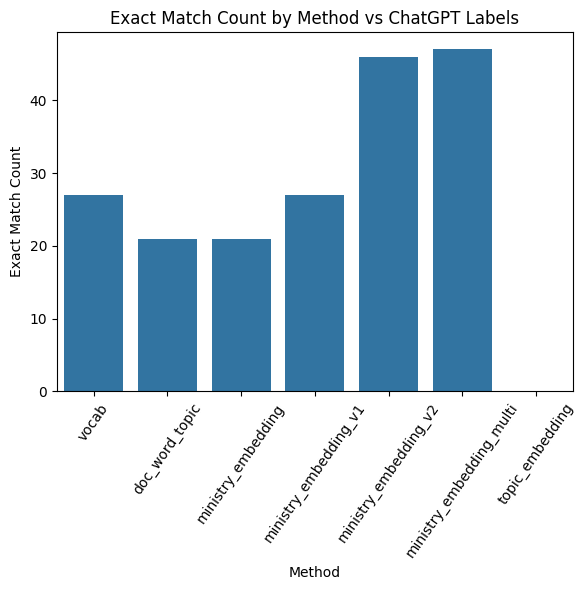

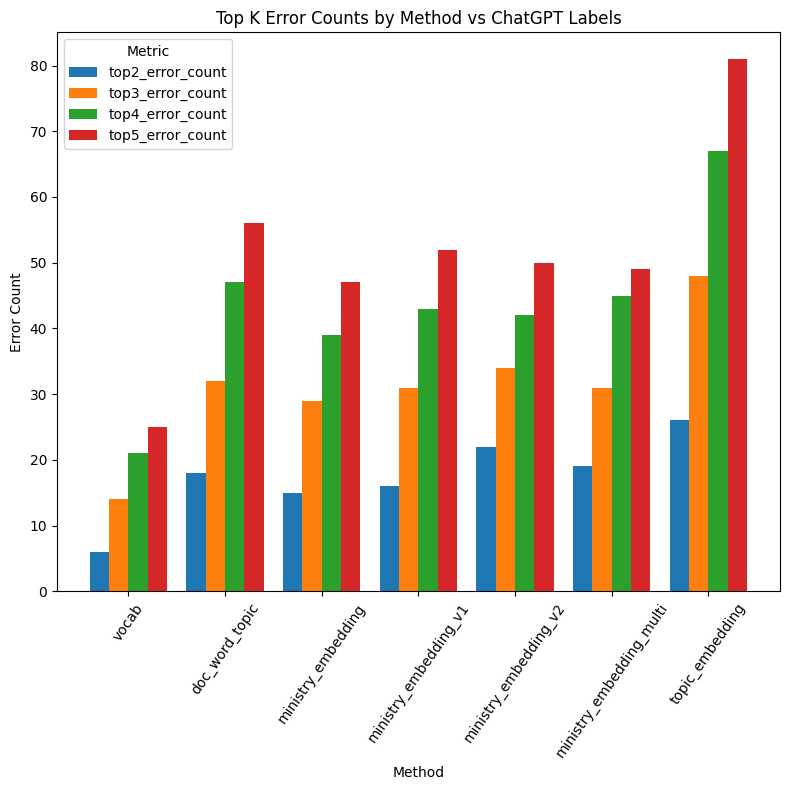

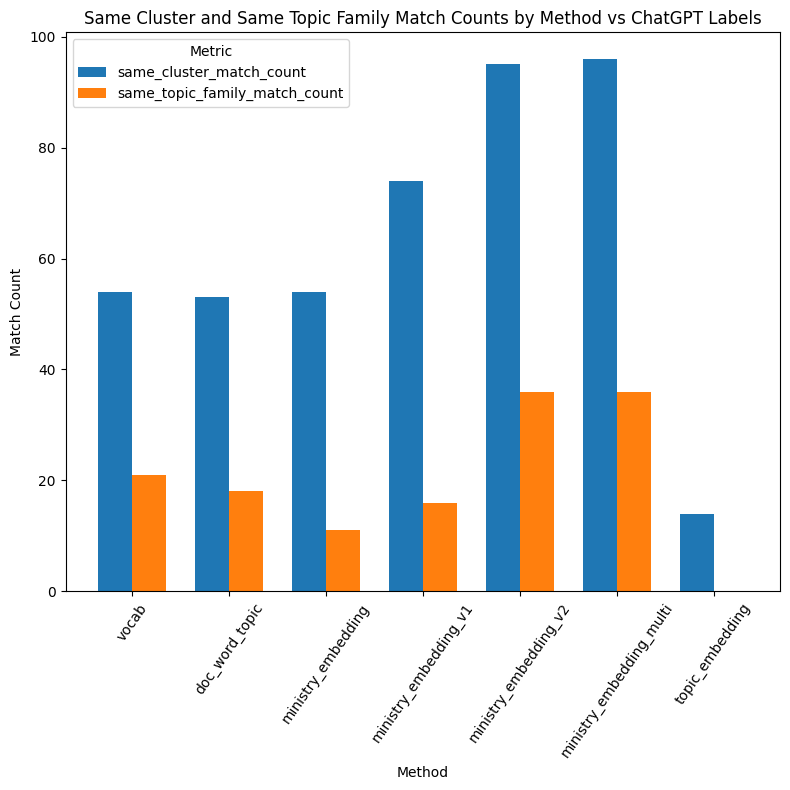

In [17]:
# i want to plot following subgraphs-
# 1. Bar chart comparing exact_match_count for each method against chatgpt_labels
# 2. Bar chart comparing top_2_error_count, top_3_error_count, top_4_error_count, top_5_error_count for each method against chatgpt_labels
# 3. Bar chart comparing same_cluster_match_count, same_topic_family_match_count for each method against chatgpt_labels

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar chart for exact_match_count
plt.figure(figsize=(6, 6))
sns.barplot(x="method", y="exact_match_count", data=results_df)
plt.title("Exact Match Count by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Exact Match Count")
plt.xticks(rotation=55)
plt.tight_layout()
plt.show()

# 2. Bar chart for top_k_error_counts (joint barr  plot, side by side bars for each error)
top_k_metrics = ["top2_error_count", "top3_error_count", "top4_error_count", "top5_error_count"]
plt.figure(figsize=(8,8))
bar_width = 0.2
index = range(len(results_df))
for i, metric in enumerate(top_k_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Top K Error Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Error Count")
plt.xticks([x + bar_width*1.5 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 3. Joint Bar chart for same_cluster_match_count and same_topic_family_match_count (2 bars side by side for each method)
match_metrics = ["same_cluster_match_count", "same_topic_family_match_count"]
plt.figure(figsize=(8,8))
bar_width = 0.35
index = range(len(results_df))
for i, metric in enumerate(match_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Same Cluster and Same Topic Family Match Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Match Count")
plt.xticks([x + bar_width/2 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [18]:
chatgpt_labels = {
0:'Ministry_of_Finance_MoF_',1:'Ministry_of_Finance_MoF_',2:'Ministry_of_Finance_MoF_',3:'Ministry_of_Finance_MoF_',4:'Ministry_of_Finance_MoF_',
5:'Ministry_of_Finance_MoF_',6:'Ministry_of_Finance_MoF_',7:'Ministry_of_Finance_MoF_',8:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
9:'Ministry_of_Heavy_Industries_MoHI_',10:'Ministry_of_Textiles_MoT_',11:'Ministry_of_Textiles_MoT_',12:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
13:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',14:'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',15:'Ministry_of_Corporate_Affairs_MCA_',
16:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',17:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',18:'Ministry_of_Ports_Shipping_and_Waterways_MoPSW_',
19:'Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_',20:'Ministry_of_Housing_and_Urban_Affairs_MoHUA_',
21:'Ministry_of_Railways_MoR_',22:'Ministry_of_Finance_MoF_',23:'Ministry_of_Corporate_Affairs_MCA_',24:'Ministry_of_Finance_MoF_',
25:'Ministry_of_Electronics_and_Information_Technology_MeitY_',26:'Ministry_of_Finance_MoF_',27:'Ministry_of_Education_MoE_',
28:'Ministry_of_Health_and_Family_Welfare_MoHFW_',29:'Ministry_of_Health_and_Family_Welfare_MoHFW_',30:'Ministry_of_AYUSH_MoA_',
31:'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_',32:'Ministry_of_Information_and_Broadcasting_MIB_',
33:'Ministry_of_Commerce_and_Industry_MoCI_',34:'Ministry_of_Education_MoE_',35:'Ministry_of_Tourism_MoT_',
36:'Ministry_of_Culture',37:'Ministry_of_Youth_Affairs_and_Sports_MoYAS_',38:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
39:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',40:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',
41:'Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_',42:'Ministry_of_Women_and_Child_Development_MoWCD_',
43:'Ministry_of_Social_Justice_and_Empowerment_MoSJE_',44:'Ministry_of_Health_and_Family_Welfare_MoHFW_',
45:'Ministry_of_Development_of_North_Eastern_Region_MDoNER_',46:'Ministry_of_Finance_MoF_',47:'Ministry_of_Finance_MoF_',
48:'Ministry_of_Finance_MoF_',49:'Ministry_of_Finance_MoF_',50:'Ministry_of_Finance_MoF_',51:'Ministry_of_Finance_MoF_',
52:'Ministry_of_Finance_MoF_',53:'Ministry_of_Finance_MoF_',54:'Ministry_of_Finance_MoF_',55:'Ministry_of_Finance_MoF_',
56:'Ministry_of_Finance_MoF_',57:'Ministry_of_Finance_MoF_',58:'Ministry_of_Finance_MoF_',59:'Ministry_of_Finance_MoF_',
60:'Ministry_of_Finance_MoF_',61:'Ministry_of_Finance_MoF_',62:'Ministry_of_Finance_MoF_',63:'Ministry_of_Finance_MoF_',
64:'Ministry_of_Finance_MoF_',65:'Ministry_of_Finance_MoF_',66:'Ministry_of_Finance_MoF_',67:'Ministry_of_Finance_MoF_',
68:'Ministry_of_Finance_MoF_',69:'Ministry_of_Finance_MoF_',70:'Ministry_of_Finance_MoF_',71:'Ministry_of_Finance_MoF_',
72:'Ministry_of_Finance_MoF_',73:'Ministry_of_Finance_MoF_',74:'Ministry_of_Finance_MoF_',75:'Ministry_of_Finance_MoF_',
76:'Ministry_of_Finance_MoF_',77:'Ministry_of_Finance_MoF_',78:'Ministry_of_Finance_MoF_',79:'Ministry_of_Finance_MoF_',
80:'Ministry_of_Finance_MoF_',81:'Ministry_of_Finance_MoF_',82:'Ministry_of_Finance_MoF_',83:'Ministry_of_Finance_MoF_',
84:'Ministry_of_Finance_MoF_',85:'Ministry_of_Finance_MoF_',86:'Ministry_of_Finance_MoF_',87:'Ministry_of_Finance_MoF_',
88:'Ministry_of_Finance_MoF_',89:'Ministry_of_Finance_MoF_',90:'Ministry_of_Finance_MoF_',91:'Ministry_of_Finance_MoF_',
92:'Ministry_of_Finance_MoF_',93:'Ministry_of_Finance_MoF_',94:'Ministry_of_Finance_MoF_',95:'Ministry_of_Finance_MoF_',
96:'Ministry_of_Finance_MoF_',97:'Ministry_of_Finance_MoF_',98:'Ministry_of_Finance_MoF_',99:'Ministry_of_Finance_MoF_',
100:'Ministry_of_Finance_MoF_',101:'Ministry_of_Finance_MoF_',102:'Ministry_of_Finance_MoF_',103:'Ministry_of_Finance_MoF_',
104:'Ministry_of_Finance_MoF_',105:'Ministry_of_Finance_MoF_',106:'Ministry_of_Finance_MoF_',107:'Ministry_of_Finance_MoF_',
108:'Ministry_of_Finance_MoF_',109:'Ministry_of_Finance_MoF_',110:'Ministry_of_Finance_MoF_',111:'Ministry_of_Finance_MoF_',
112:'Ministry_of_Finance_MoF_',113:'Ministry_of_Finance_MoF_',114:'Ministry_of_Finance_MoF_',115:'Ministry_of_Finance_MoF_',
116:'Ministry_of_Finance_MoF_',117:'Ministry_of_Finance_MoF_',118:'Ministry_of_Finance_MoF_',119:'Ministry_of_Finance_MoF_',
120:'Ministry_of_Finance_MoF_',121:'Ministry_of_Finance_MoF_',122:'Ministry_of_Finance_MoF_',123:'Ministry_of_Finance_MoF_',
124:'Ministry_of_Finance_MoF_',125:'Ministry_of_Finance_MoF_',126:'Ministry_of_Finance_MoF_',127:'Ministry_of_Finance_MoF_',
128:'Ministry_of_Finance_MoF_',129:'Ministry_of_Finance_MoF_',130:'Ministry_of_Finance_MoF_',131:'Ministry_of_Finance_MoF_',
132:'Ministry_of_Finance_MoF_',133:'Ministry_of_Finance_MoF_',134:'Ministry_of_Finance_MoF_',135:'Ministry_of_Finance_MoF_',
136:'Ministry_of_Finance_MoF_',137:'Ministry_of_Finance_MoF_',138:'Ministry_of_Finance_MoF_',139:'Ministry_of_Finance_MoF_',
140:'Ministry_of_Finance_MoF_',141:'Ministry_of_Finance_MoF_',142:'Ministry_of_Finance_MoF_',143:'Ministry_of_Finance_MoF_',
144:'Ministry_of_Finance_MoF_',145:'Ministry_of_Finance_MoF_',146:'Ministry_of_Finance_MoF_',147:'Ministry_of_Finance_MoF_',
148:'Ministry_of_Finance_MoF_',149:'Ministry_of_Finance_MoF_',150:'Ministry_of_Finance_MoF_',151:'Ministry_of_Finance_MoF_',
152:'Ministry_of_Finance_MoF_',153:'Ministry_of_Finance_MoF_',154:'Ministry_of_Finance_MoF_'
}

In [19]:
# Store all results
new_all_results = []

for method_name in methods_config.keys():
    method_config = methods_config[method_name]
    
    print(f"\n{'='*60}")
    print(f"Testing: {method_name} vs baseline: chatgpt_labels")
    print(f"{'='*60}")
    
    try:
        # Build configuration
        cfg = ClassificationConfig(
            pdf_path="data/uploads/bs_2026-27.pdf",
            method=method_config["method"],
            reference_labels=chatgpt_labels,
            topic_state_file="data/topic_modeling/state.csv",
            ministry_profiles_dir="data/ministry_profiles",
            stopword_files=("data/stopwords/GBparl_stopwords-empirical.txt", "data/stopwords/stopwords.txt"),
            validator_vocab_path="data/vocabulary/parliament_vocab.txt",
            vocab_file="data/vocabulary/ministry_tfidf_vocab.json",
            ministry_embedding_file=method_config["params"].get("embedding_file", "data/embeddings/ministry_embeddings.json"),
            topic_embedding_file="data/embeddings/topic_embeddings.json",
            topic_mapping_file="data/topic_modeling/top_ministry_per_topic.csv",
            model_name="all-MiniLM-L6-v2",
            model_cache_folder="models",
            ministry_clusters=clusters,
        )
        
        # Add extra params if needed
        if "aggregation" in method_config["params"]:
            cfg.primary_params = {"aggregation": method_config["params"]["aggregation"], "top_k": method_config["params"]["top_k"]}
        
        # Run pipeline
        output = run_classification_pipeline(cfg)
        
        # Extract metrics and store
        metrics = output.get("metrics", {})
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            **metrics
        }
        new_all_results.append(result_row)
        
        print(f"✓ Success - Metrics: {metrics}")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        result_row = {
            "method": method_name,
            "baseline_method": "chatgpt_labels",
            "error": str(e)
        }
        new_all_results.append(result_row)



Testing: vocab vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 155, 'exact_match_count': 12, 'exact_match_rate': 0.07741935483870968, 'top2_error_count': 13, 'top3_error_count': 20, 'top4_error_count': 25, 'top5_error_count': 29, 'top2_error_rate': 0.08387096774193549, 'top3_error_rate': 0.12903225806451613, 'top4_error_rate': 0.16129032258064516, 'top5_error_rate': 0.1870967741935484, 'same_cluster_match_count': 31, 'same_cluster_match_rate': 0.2, 'same_topic_family_match_count': 12, 'same_topic_family_match_rate': 0.07741935483870968}

Testing: doc_word_topic vs baseline: chatgpt_labels
✓ Success - Metrics: {'num_paragraphs': 155, 'exact_match_count': 12, 'exact_match_rate': 0.07741935483870968, 'top2_error_count': 14, 'top3_error_count': 26, 'top4_error_count': 36, 'top5_error_count': 45, 'top2_error_rate': 0.09032258064516129, 'top3_error_rate': 0.16774193548387098, 'top4_error_rate': 0.23225806451612904, 'top5_error_rate': 0.2903225806451613, 'same_cluster_mat

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 155, 'exact_match_count': 14, 'exact_match_rate': 0.09032258064516129, 'top2_error_count': 10, 'top3_error_count': 20, 'top4_error_count': 29, 'top5_error_count': 36, 'top2_error_rate': 0.06451612903225806, 'top3_error_rate': 0.12903225806451613, 'top4_error_rate': 0.1870967741935484, 'top5_error_rate': 0.23225806451612904, 'same_cluster_match_count': 56, 'same_cluster_match_rate': 0.36129032258064514, 'same_topic_family_match_count': 14, 'same_topic_family_match_rate': 0.09032258064516129}

Testing: ministry_embedding_v1 vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 155, 'exact_match_count': 41, 'exact_match_rate': 0.2645161290322581, 'top2_error_count': 14, 'top3_error_count': 26, 'top4_error_count': 31, 'top5_error_count': 35, 'top2_error_rate': 0.09032258064516129, 'top3_error_rate': 0.16774193548387098, 'top4_error_rate': 0.2, 'top5_error_rate': 0.22580645161290322, 'same_cluster_match_count': 84, 'same_cluster_match_rate': 0.5419354838709678, 'same_topic_family_match_count': 41, 'same_topic_family_match_rate': 0.2645161290322581}

Testing: topic_embedding vs baseline: chatgpt_labels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Success - Metrics: {'num_paragraphs': 155, 'exact_match_count': 0, 'exact_match_rate': 0.0, 'top2_error_count': 29, 'top3_error_count': 51, 'top4_error_count': 56, 'top5_error_count': 68, 'top2_error_rate': 0.1870967741935484, 'top3_error_rate': 0.32903225806451614, 'top4_error_rate': 0.36129032258064514, 'top5_error_rate': 0.43870967741935485, 'same_cluster_match_count': 5, 'same_cluster_match_rate': 0.03225806451612903, 'same_topic_family_match_count': 0, 'same_topic_family_match_rate': 0.0}


In [20]:
results_df = pd.DataFrame(new_all_results)
print(results_df.to_string())

                     method baseline_method  num_paragraphs  exact_match_count  exact_match_rate  top2_error_count  top3_error_count  top4_error_count  top5_error_count  top2_error_rate  top3_error_rate  top4_error_rate  top5_error_rate  same_cluster_match_count  same_cluster_match_rate  same_topic_family_match_count  same_topic_family_match_rate
0                     vocab  chatgpt_labels             155                 12          0.077419                13                20                25                29         0.083871         0.129032         0.161290         0.187097                        31                 0.200000                             12                      0.077419
1            doc_word_topic  chatgpt_labels             155                 12          0.077419                14                26                36                45         0.090323         0.167742         0.232258         0.290323                        43                 0.277419               

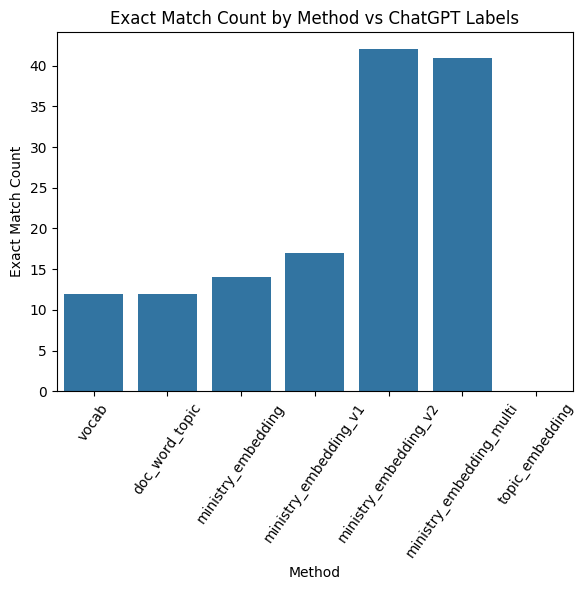

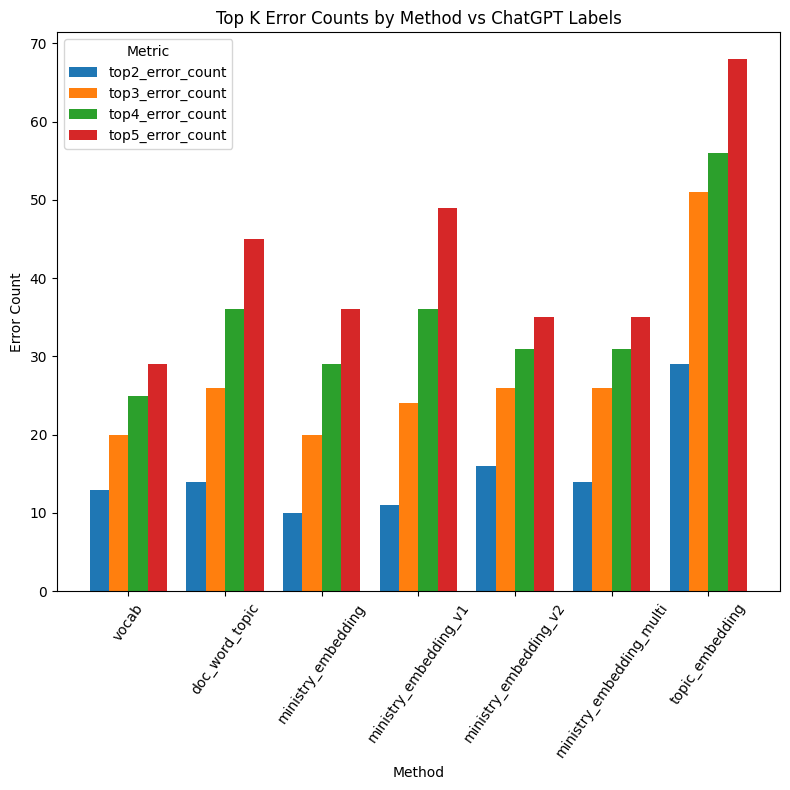

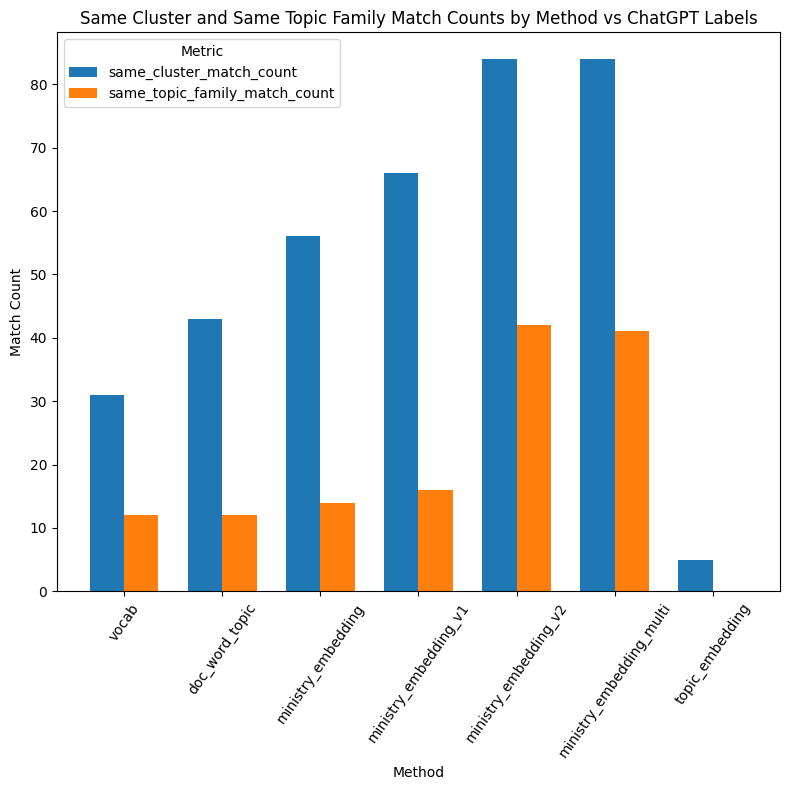

In [21]:
# i want to plot following subgraphs-
# 1. Bar chart comparing exact_match_count for each method against chatgpt_labels
# 2. Bar chart comparing top_2_error_count, top_3_error_count, top_4_error_count, top_5_error_count for each method against chatgpt_labels
# 3. Bar chart comparing same_cluster_match_count, same_topic_family_match_count for each method against chatgpt_labels

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar chart for exact_match_count
plt.figure(figsize=(6, 6))
sns.barplot(x="method", y="exact_match_count", data=results_df)
plt.title("Exact Match Count by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Exact Match Count")
plt.xticks(rotation=55)
plt.tight_layout()
plt.show()

# 2. Bar chart for top_k_error_counts (joint barr  plot, side by side bars for each error)
top_k_metrics = ["top2_error_count", "top3_error_count", "top4_error_count", "top5_error_count"]
plt.figure(figsize=(8,8))
bar_width = 0.2
index = range(len(results_df))
for i, metric in enumerate(top_k_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Top K Error Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Error Count")
plt.xticks([x + bar_width*1.5 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 3. Joint Bar chart for same_cluster_match_count and same_topic_family_match_count (2 bars side by side for each method)
match_metrics = ["same_cluster_match_count", "same_topic_family_match_count"]
plt.figure(figsize=(8,8))
bar_width = 0.35
index = range(len(results_df))
for i, metric in enumerate(match_metrics):
    plt.bar([x + i*bar_width for x in index], results_df[metric], width=bar_width, label=metric)
plt.title("Same Cluster and Same Topic Family Match Counts by Method vs ChatGPT Labels")
plt.xlabel("Method")
plt.ylabel("Match Count")
plt.xticks([x + bar_width/2 for x in index], results_df["method"], rotation=55)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()